<a href="https://colab.research.google.com/github/YashmithaChandrakumar/EV_Demand_Prediction/blob/main/bank_fraud_detection_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Bank Fraud Detection using Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

import shap
import joblib
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")


Libraries imported successfully



# Step 1: Load Dataset


In [ ]:
df = pd.read_csv("/content/creditcard.csv")

print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

print("\nFraud Distribution:")
print(df['Class'].value_counts())

print("\nFraud Percentage:")
print(df['Class'].value_counts(normalize=True) * 100)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28


# Step 2: Data Preprocessing


In [ ]:
# Check missing values
print(df.isnull().sum())
# Remove rows where Class is NaN
df = df.dropna(subset=["Class"])
# Make sure Class is integer
df["Class"] = df["Class"].astype(int)

# Features and target

X = df.drop("Class", axis=1)
y = df["Class"]

# Train test split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape, X_test.shape)


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
(227845, 30) (56962, 30)


In [ ]:

# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")


Scaling completed



# Step 3: Handle Imbalanced Dataset using SMOTE


In [ ]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())


Before SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64



# Step 4: Logistic Regression Model


In [ ]:
log_model = LogisticRegression()

log_model.fit(X_train_resampled, y_train_resampled)

y_pred_log = log_model.predict(X_test_scaled)
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962




# Step 5: Random Forest Model


In [ ]:
rf_model = RandomForestClassifier(n_estimators=50, max_depth=10,random_state=42,class_weight="balanced",n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.43      0.86      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.93      0.79     56962
weighted avg       1.00      1.00      1.00     56962




# Step 6: XGBoost Model (Industry Preferred)


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_xgb))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.49      0.86      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.93      0.81     56962
weighted avg       1.00      1.00      1.00     56962




# Step 7: Threshold Optimization

Optimize threshold to reduce false negatives.


In [ ]:

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

best_threshold = 0.5
best_score = 0

for t in thresholds:
    preds = (y_prob_xgb >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    recall_score = tp / (tp + fn)
    fp_rate = fp / (fp + tn)

    if recall_score >= 0.80 and fp_rate < 0.05:
        best_threshold = t
        best_score = recall_score

print("Optimal Threshold:", best_threshold)
print("Recall Achieved:", best_score)


Optimal Threshold: 0.96279615
Recall Achieved: 0.8061224489795918



# Step 8: SHAP Explainability


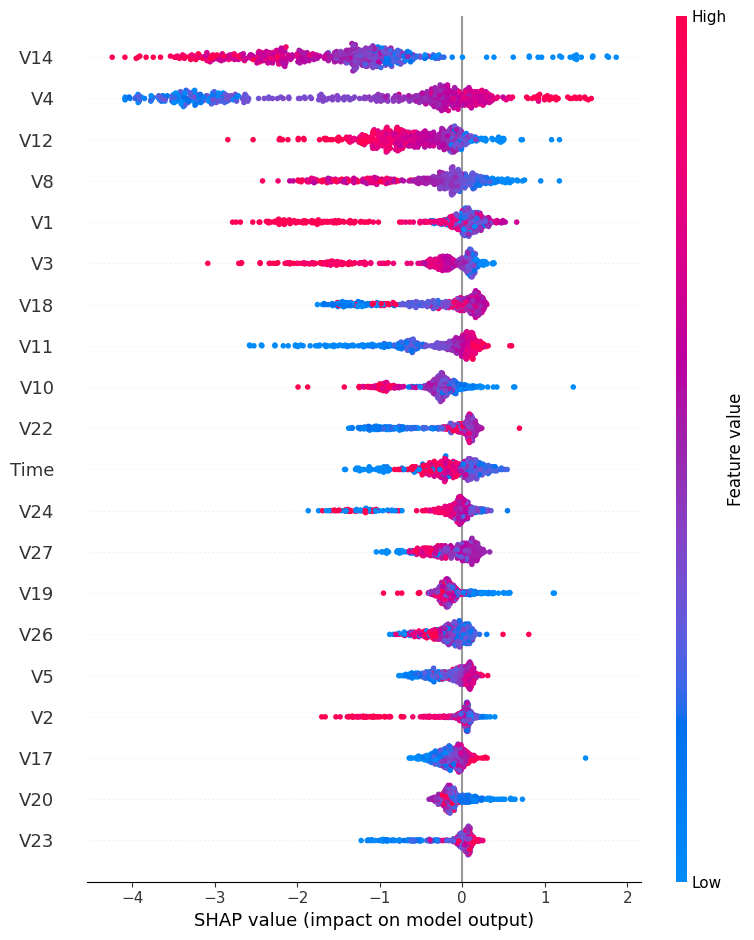

In [ ]:
explainer = shap.TreeExplainer(xgb_model)

sample_data = X_test_scaled[:500]

shap_values = explainer.shap_values(sample_data)

shap.summary_plot(
    shap_values,
    sample_data,
    feature_names=X.columns
)



# Step 9: Unsupervised Anomaly Detection using Isolation Forest


In [ ]:
iso_model = IsolationForest(
    contamination=0.01,
    random_state=42
)

iso_model.fit(X_train_scaled)

iso_preds = iso_model.predict(X_test_scaled)

# Convert predictions
iso_preds = np.where(iso_preds == -1, 1, 0)

print(classification_report(y_test, iso_preds))


              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.66      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.83      0.59     56962
weighted avg       1.00      0.99      0.99     56962




# Step 10: Model Evaluation


In [ ]:
auc_score = roc_auc_score(y_test, y_prob_xgb)

print("ROC AUC Score:", auc_score)

cm = confusion_matrix(y_test, y_pred_xgb)

print("\nConfusion Matrix")
print(cm)


ROC AUC Score: 0.9809766302412918

Confusion Matrix
[[56778    86]
 [   14    84]]


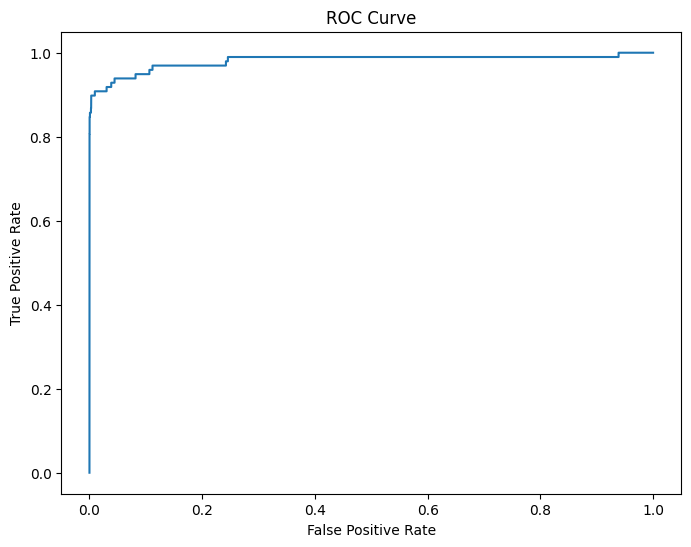

In [ ]:

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()



# Step 11: Save Model


In [ ]:

joblib.dump(xgb_model, "fraud_detection_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully")


Model saved successfully



# Step 12: FastAPI Deployment


In [ ]:

fastapi_code = '''
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()

model = joblib.load("fraud_detection_model.pkl")
scaler = joblib.load("scaler.pkl")

@app.get("/")
def home():
    return {"message": "Fraud Detection API Running"}

@app.post("/predict")
def predict(data: dict):

    values = np.array(list(data.values())).reshape(1, -1)

    scaled = scaler.transform(values)

    prediction = model.predict(scaled)[0]
    probability = model.predict_proba(scaled)[0][1]

    return {
        "fraud_prediction": int(prediction),
        "fraud_probability": float(probability)
    }
'''

with open("app.py", "w") as f:
    f.write(fastapi_code)

print("FastAPI app created")


FastAPI app created



# Step 13: Streamlit Dashboard


In [ ]:

streamlit_code = '''
import streamlit as st
import pandas as pd
import joblib

model = joblib.load("fraud_detection_model.pkl")

st.title("Bank Fraud Detection Dashboard")

uploaded_file = st.file_uploader("Upload Transaction CSV")

if uploaded_file:

    df = pd.read_csv(uploaded_file)

    predictions = model.predict(df)

    df['Fraud_Prediction'] = predictions

    st.write(df.head())

    fraud_count = sum(predictions)

    st.metric("Fraud Transactions", fraud_count)
'''

with open("streamlit_app.py", "w") as f:
    f.write(streamlit_code)

print("Streamlit app created")


Streamlit app created



# Step 14: Docker Deployment


In [ ]:

dockerfile = '''
FROM python:3.11

WORKDIR /app

COPY . .

RUN pip install -r requirements.txt

EXPOSE 8000

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
'''

with open("Dockerfile", "w") as f:
    f.write(dockerfile)

print("Dockerfile created")


Dockerfile created



# Step 16: Drift Detection using Evidently AI


In [ ]:
from evidently.report import Report
from evidently.metric_preset import DataDriftPreset

reference_data = df.sample(5000, random_state=42)
current_data = df.sample(5000, random_state=1)

report = Report(metrics=[DataDriftPreset()])

report.run(
    reference_data=reference_data,
    current_data=current_data
)

report.save_html("drift_report.html")

print("Drift report generated")


Drift report generated
